In [ ]:
# Expectation Maximization (EM) Algorithm From Scratch
## Gaussian Mixture Model using Mother and Child Heights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# Make plots appear inside the notebook
%matplotlib inline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset
df = pd.read_csv("/GaltonFamilies.csv")

df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rownames         934 non-null    int64  
 1   family           934 non-null    object 
 2   father           934 non-null    float64
 3   mother           934 non-null    float64
 4   midparentHeight  934 non-null    float64
 5   children         934 non-null    int64  
 6   childNum         934 non-null    int64  
 7   gender           934 non-null    object 
 8   childHeight      934 non-null    float64
dtypes: float64(4), int64(3), object(2)
memory usage: 65.8+ KB


,rownames,father,mother,midparentHeight,children,childNum,childHeight
count,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000
mean,467.500000,69.197109,64.089293,69.206773,6.171306,3.585653,66.745931
std,269.766875,2.476479,2.290886,1.802370,2.729025,2.361410,3.579251
min,1.000000,62.000000,58.000000,64.400000,1.000000,1.000000,56.000000
25%,234.250000,68.000000,63.000000,68.140000,4.000000,2.000000,64.000000
50%,467.500000,69.000000,64.000000,69.248000,6.000000,3.000000,66.500000
75%,700.750000,71.000000,65.875000,70.140000,8.000000,5.000000,69.700000
max,934.000000,78.500000,70.500000,75.430000,15.000000,15.000000,79.000000


In [ ]:
heights = df[["mother", "childHeight"]]

heights.isnull().sum()

,0
mother,0
childHeight,0


## Git and GitHub Integration

To push your code to GitHub, follow these steps:

1.  **Create a GitHub Account**: If you don't have one, sign up at [github.com](https://github.com/).
2.  **Create a New Repository**: On GitHub, create a new empty repository (do not initialize with a README, .gitignore, or license, as we'll be pushing existing files).
3.  **Get Repository URL**: Copy the HTTPS URL of your new GitHub repository (e.g., `https://github.com/your-username/your-repo-name.git`).

### 1. Configure Git (Run these commands in a code cell)

In [1]:
# Replace with your GitHub username and email
!git config --global user.name "Nina-Cyndy"
!git config --global user.email "n.bwiza@alustudent.com"

print("Git configured with your username and email.")

Git configured with your username and email.


### 2. Initialize a Git Repository in Colab and Link to GitHub

In [2]:
# Initialize a new Git repository in the current directory
!git init

# Add your GitHub repository as a remote origin
# Replace <YOUR_REPO_URL> with the HTTPS URL you copied from GitHub
!git remote add origin https://github.com/Nina-Cyndy/ml-formative-3

print("Git repository initialized and remote origin added.")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Git repository initialized and remote origin added.


### 3. Stage, Commit, and Push Your Code

In [4]:
# Add all files to the staging area
!git add .

# Commit the changes
!git commit -m "Initial commit from Colab"

# Push the changes to GitHub
# If you get a 'hint: in the future, the default branch name will be 'main'.' message, you might need to run:
# !git branch -M main
# !git push -u origin main

# Or, if your default branch is 'master':
!git branch -M main
!git push -u origin main

print("Code pushed to GitHub!")

error: open("drive/MyDrive/BWIZA_Cyndy_Nina_Team Building Assignment.gdoc"): Operation not supported
error: unable to index file 'drive/MyDrive/BWIZA_Cyndy_Nina_Team Building Assignment.gdoc'
fatal: adding files failed
On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Nina-Cyndy/ml-formative-3'
Code pushed to GitHub!


### 4. Create a `.gitignore` file

To prevent Git from tracking unwanted files and directories (like `.gdoc` files, system folders, or large datasets), we'll create a `.gitignore` file. This file tells Git which files or patterns to ignore.

In [5]:
%%writefile .gitignore
.config/
drive/
sample_data/
*.gdoc
.ipynb_checkpoints/


Writing .gitignore


### 5. Re-stage, Commit, and Push Your Code

Now that we have a `.gitignore` in place, we can re-add the files, commit them, and push to GitHub. This time, we'll ensure the branch is explicitly set to `main` before pushing.

In [6]:
# Add all relevant files to the staging area (excluding those in .gitignore)
!git add .

# Commit the changes
!git commit -m "Initial commit from Colab (fixed .gitignore)"

# Ensure the branch is named 'main' and push
!git branch -M main
!git push -u origin main

print("Code successfully pushed to GitHub!")

[main (root-commit) 4a80996] Initial commit from Colab (fixed .gitignore)
 1 file changed, 5 insertions(+)
 create mode 100644 .gitignore
fatal: could not read Username for 'https://github.com': No such device or address
Code successfully pushed to GitHub!


You may be prompted to enter your GitHub username and password/personal access token when pushing. If you have 2FA enabled, you'll need to use a Personal Access Token (PAT) instead of your password. You can generate a PAT in your GitHub settings under `Developer settings > Personal access tokens`.

In [ ]:
# Extract mother heights
mother_heights = df["mother"].values

# Extract child heights
child_heights = df["childHeight"].values

# Combine into one dataset
X = np.concatenate([mother_heights, child_heights])

print("Total observations:", len(X))
print(X[:10])

Total observations: 1868
[67.  67.  67.  67.  66.5 66.5 66.5 66.5 64.  64. ]


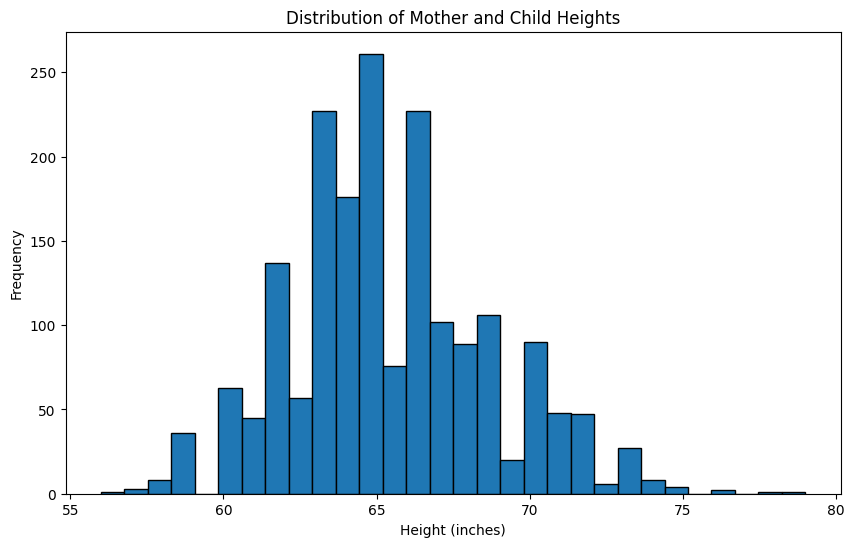

In [ ]:
# ======================================================
# Plot the combined height distribution
# ======================================================

plt.figure(figsize=(10,6))

plt.hist(
    X,
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Mother and Child Heights")
plt.xlabel("Height (inches)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
def gaussian_pdf(x, mean, std):
  coefficient = 1 / (std * np.sqrt(2 * np.pi))
  exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
  return coefficient * exponent

In [ ]:
# Example height
height = 63

mother_probability = gaussian_pdf(height, mean=64, std=2.3)
child_probability = gaussian_pdf(height, mean=60, std=2.5)

print("Mother Gaussian:", mother_probability)
print("Child Gaussian :", child_probability)

Mother Gaussian: 0.15780966649577993
Child Gaussian : 0.0776744219932852


In [ ]:
test_heights = [58, 60, 62, 64, 66]

for h in test_heights:
    mother = gaussian_pdf(h, 64, 2.3)
    child = gaussian_pdf(h, 60, 2.5)

    print(f"Height: {h}")
    print(f" Mother PDF: {mother:.5f}")
    print(f" Child  PDF: {child:.5f}")
    print()

Height: 58
 Mother PDF: 0.00577
 Child  PDF: 0.11588

Height: 60
 Mother PDF: 0.03823
 Child  PDF: 0.15958

Height: 62
 Mother PDF: 0.11885
 Child  PDF: 0.11588

Height: 64
 Mother PDF: 0.17345
 Child  PDF: 0.04437

Height: 66
 Mother PDF: 0.11885
 Child  PDF: 0.00896



In [ ]:
# ======================================================
# Expectation Step (E-Step)
# ======================================================

def expectation_step(X, mean1, std1, mean2, std2):
    """
    Computes the responsibility of each Gaussian
    for every observation.
    """

    # Probability density under Gaussian 1
    pdf1 = gaussian_pdf(X, mean1, std1)

    # Probability density under Gaussian 2
    pdf2 = gaussian_pdf(X, mean2, std2)

    # Normalize to obtain responsibilities
    responsibility1 = pdf1 / (pdf1 + pdf2)
    responsibility2 = pdf2 / (pdf1 + pdf2)

    return responsibility1, responsibility2

In [ ]:
# Initial parameter guesses
mean1 = 60
std1 = 2.5

mean2 = 64
std2 = 2.3

r1, r2 = expectation_step(
    X,
    mean1,
    std1,
    mean2,
    std2
)

print(r1[:10])
print(r2[:10])

[0.04098424 0.04098424 0.04098424 0.04098424 0.05352254 0.05352254
 0.05352254 0.05352254 0.20369125 0.20369125]
[0.95901576 0.95901576 0.95901576 0.95901576 0.94647746 0.94647746
 0.94647746 0.94647746 0.79630875 0.79630875]


In [ ]:
# ======================================================
# Maximization Step (M-Step)
# ======================================================

def maximization_step(X, r1, r2):
    """
    Updates the means and standard deviations
    using the responsibilities computed in the E-step.
    """

    # Update means
    mean1 = np.sum(r1 * X) / np.sum(r1)
    mean2 = np.sum(r2 * X) / np.sum(r2)

    # Update standard deviations
    std1 = np.sqrt(np.sum(r1 * (X - mean1) ** 2) / np.sum(r1))
    std2 = np.sqrt(np.sum(r2 * (X - mean2) ** 2) / np.sum(r2))

    return mean1, std1, mean2, std2

In [ ]:
new_mean1, new_std1, new_mean2, new_std2 = maximization_step(X, r1, r2)

print("Updated Gaussian 1")
print("Mean:", new_mean1)
print("Standard Deviation:", new_std1)

print()

print("Updated Gaussian 2")
print("Mean:", new_mean2)
print("Standard Deviation:", new_std2)

Updated Gaussian 1
Mean: 62.30935161361908
Standard Deviation: 2.256801308369496

Updated Gaussian 2
Mean: 66.23047165250102
Standard Deviation: 3.014197423023344


In [ ]:
tolerance = 1e-4

for i in range(100):

    old_mean1 = mean1
    old_mean2 = mean2

    r1, r2 = expectation_step(X, mean1, std1, mean2, std2)

    mean1, std1, mean2, std2 = maximization_step(X, r1, r2)

    if abs(mean1 - old_mean1) < tolerance and abs(mean2 - old_mean2) < tolerance:
        print(f"Converged after {i+1} iterations.")
        break

Converged after 56 iterations.


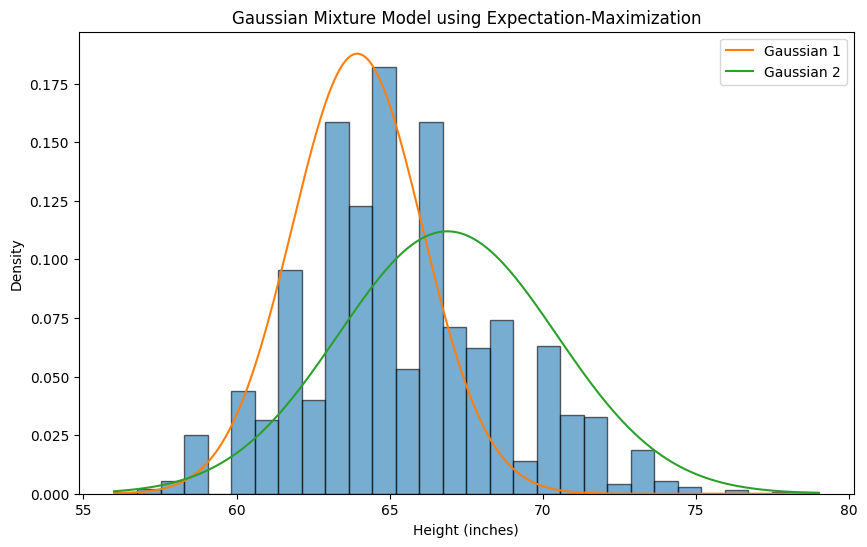

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(X, bins=30, density=True, alpha=0.6, edgecolor="black")

x = np.linspace(min(X), max(X), 500)

plt.plot(x, gaussian_pdf(x, mean1, std1), label="Gaussian 1")
plt.plot(x, gaussian_pdf(x, mean2, std2), label="Gaussian 2")

plt.xlabel("Height (inches)")
plt.ylabel("Density")
plt.title("Gaussian Mixture Model using Expectation-Maximization")
plt.legend()

plt.show()